In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
df = pd.read_csv("../data/processed/cleaned_churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_missing,TotalCharges_missing
0,CUST00001,Male,0.0,No,Yes,3.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes,0,0
1,CUST00002,Male,1.0,Yes,No,2.0,Yes,Yes,DSL,No,No,No internet service,Yes,No internet service,No,One year,Yes,Bank transfer (automatic),23.15,46.30,No,0,0
2,CUST00003,Female,0.0,No,No,42.0,Yes,Yes,DSL,No,Yes,No,No internet service,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes,0,0
3,CUST00004,Female,0.0,No,Yes,40.0,Yes,Yes,Fiber optic,No,No,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.60,No,0,0
4,CUST00005,Male,1.0,Yes,Yes,17.0,Yes,No,Fiber optic,Yes,No,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes,0,0


In [4]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (70000, 23)

Data types:
customerID               object
gender                   object
SeniorCitizen           float64
Partner                  object
Dependents               object
tenure                  float64
PhoneService             object
MultipleLines            object
InternetService          object
OnlineSecurity           object
OnlineBackup             object
DeviceProtection         object
TechSupport              object
StreamingTV              object
StreamingMovies          object
Contract                 object
PaperlessBilling         object
PaymentMethod            object
MonthlyCharges          float64
TotalCharges            float64
Churn                    object
tenure_missing            int64
TotalCharges_missing      int64
dtype: object

Missing values:
customerID                 0
gender                     0
SeniorCitizen            659
Partner                    0
Dependents                 0
tenure                  1729
PhoneService               

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,70000,70000,CUST00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,70000,3,Female,34787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,69341.0,NaN,NaN,NaN,0.201136,0.400853,0.0,0.0,0.0,0.0,1.0
Partner,70000,3,No,38344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,70000,3,No,45375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,68271.0,NaN,NaN,NaN,31.163993,90.496654,1.0,10.0,21.0,35.0,999.0
PhoneService,70000,2,Yes,63011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,70000,3,Yes,34631,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,70000,3,Fiber optic,38502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,70000,3,No,39195,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
##Define useful groups
target_col = "Churn"

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

if "SeniorCitizen" in df.columns:
    df["SeniorCitizen"] = df["SeniorCitizen"].replace({0: "No", 1: "Yes", "0": "No", "1": "Yes"})
    
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

Univariate analysis

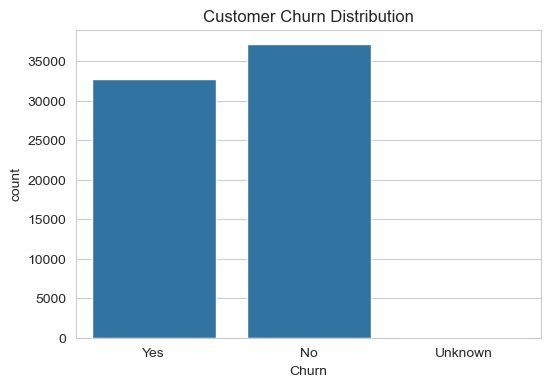

,count,percent
Churn,,
No,37148,53.07
Yes,32798,46.85
Unknown,54,0.08


In [7]:
##1 Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

churn_dist = df["Churn"].value_counts(dropna=False)
churn_pct = df["Churn"].value_counts(normalize=True, dropna=False) * 100

summary_churn = pd.DataFrame({
    "count": churn_dist,
    "percent": churn_pct.round(2)
})
summary_churn

The target is strongly imbalanced.

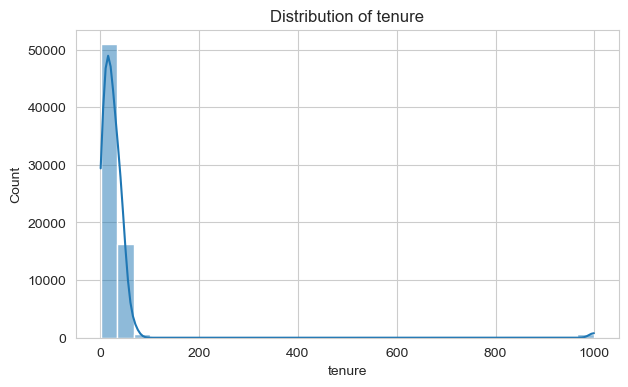

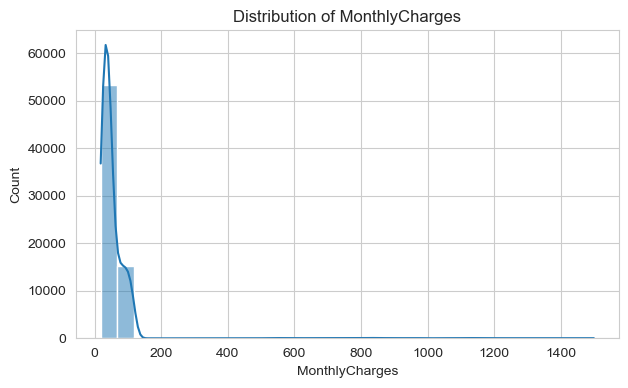

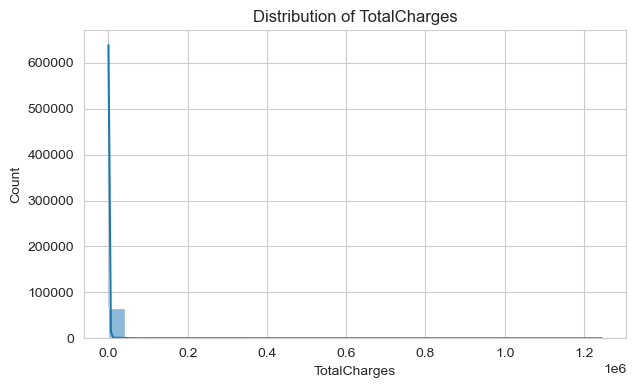

In [10]:
##2 Numeric distributions
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()


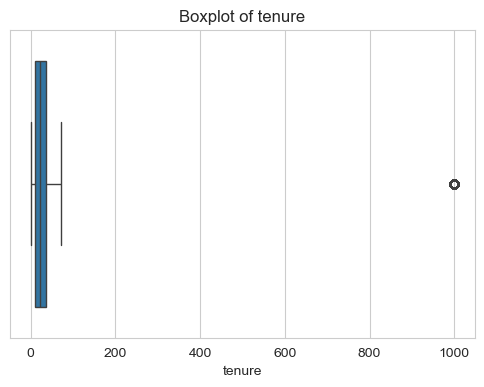

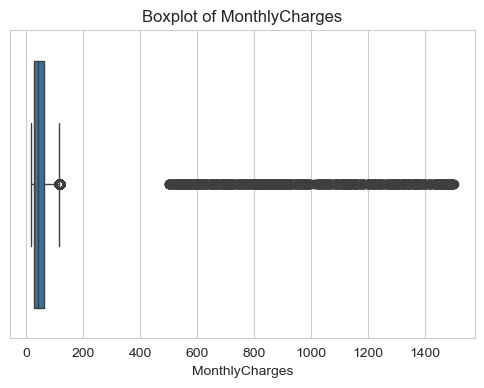

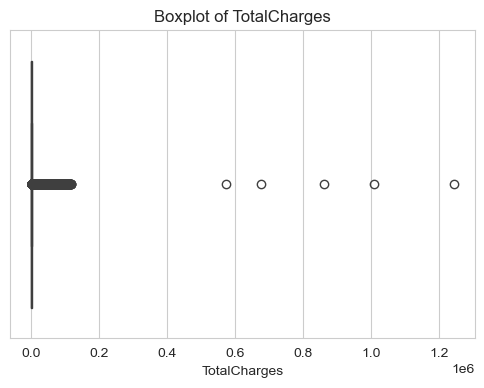

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

1- tenure is concentrated at low values 
2- charges are skewed with many outliers 
3- total charges contain extreme values as well

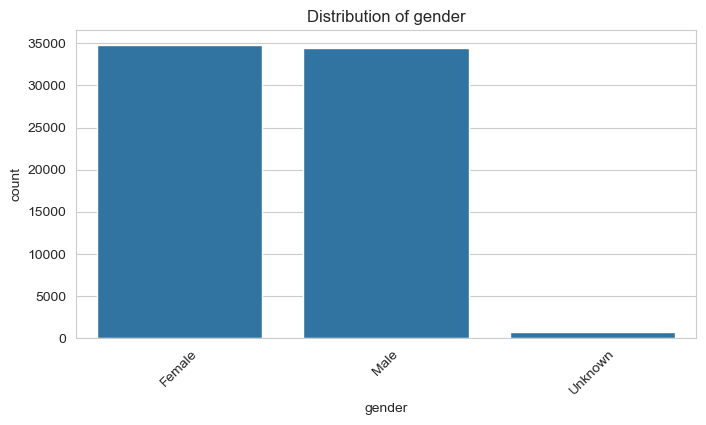

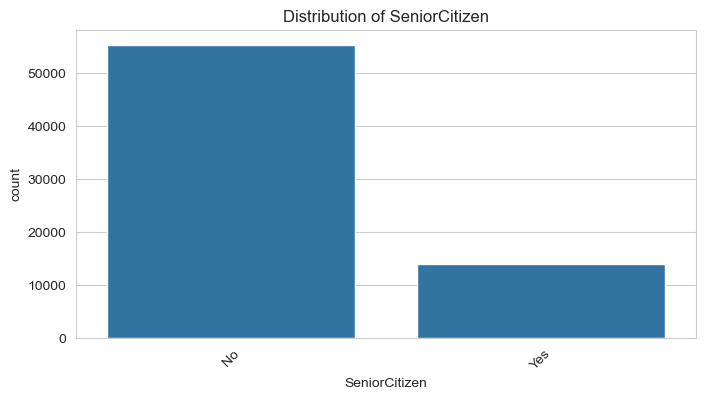

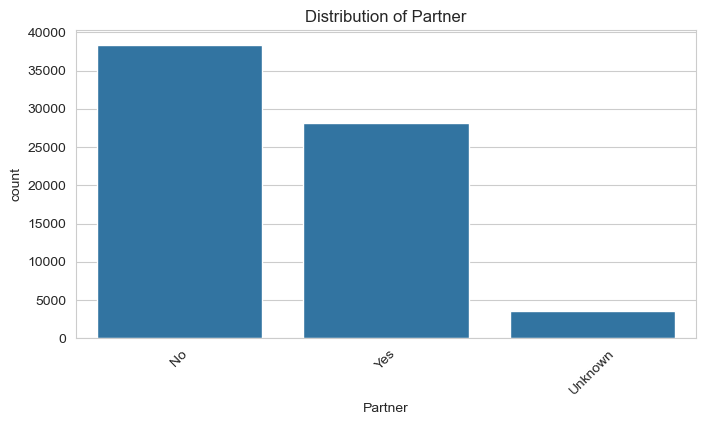

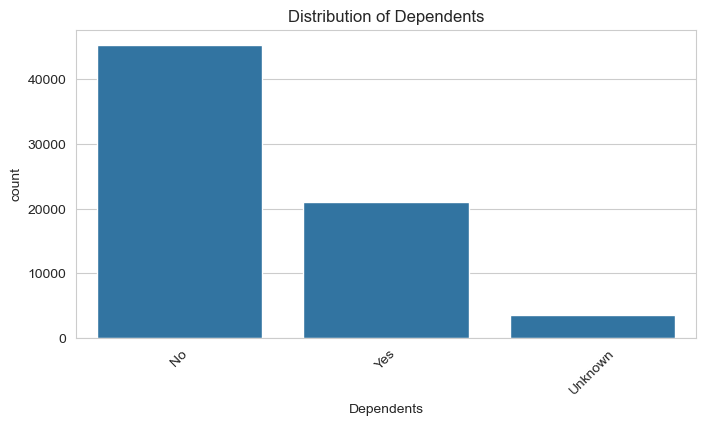

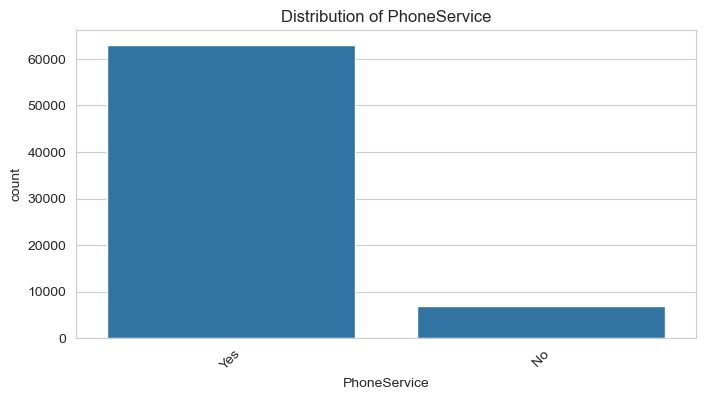

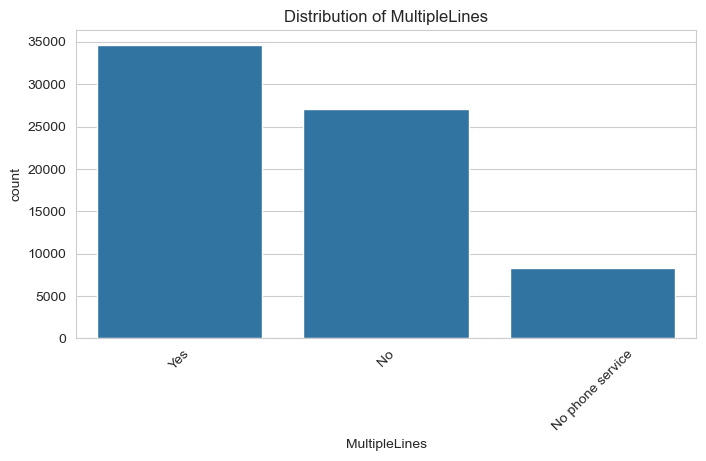

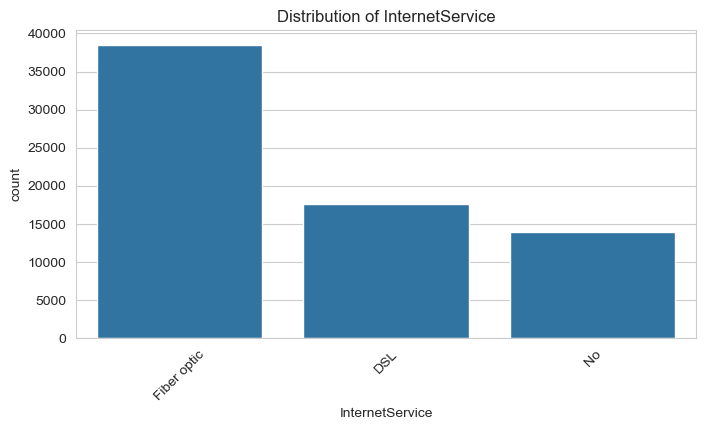

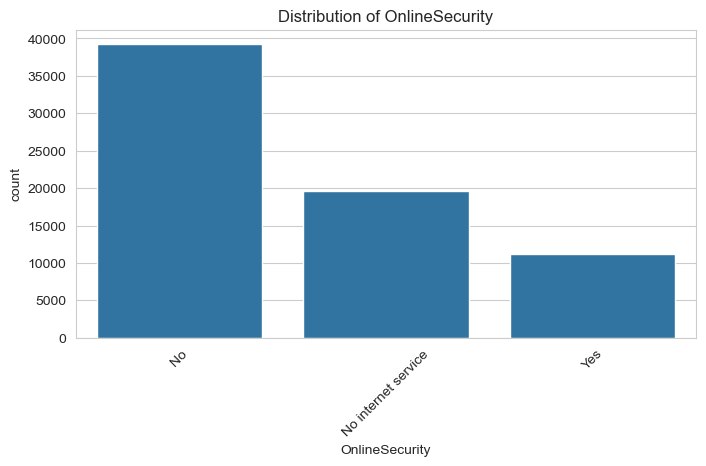

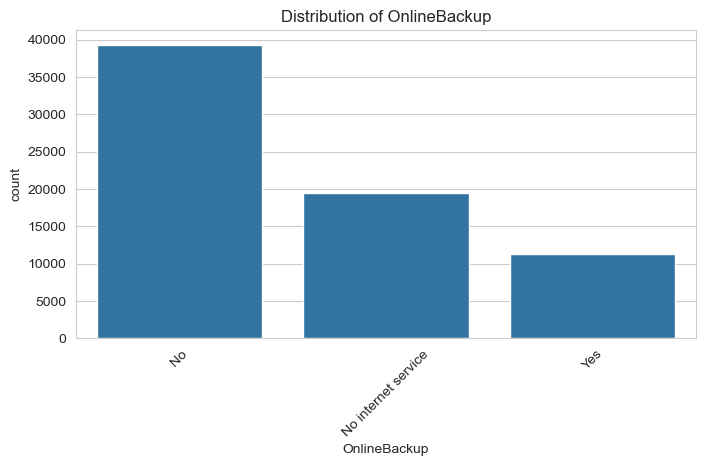

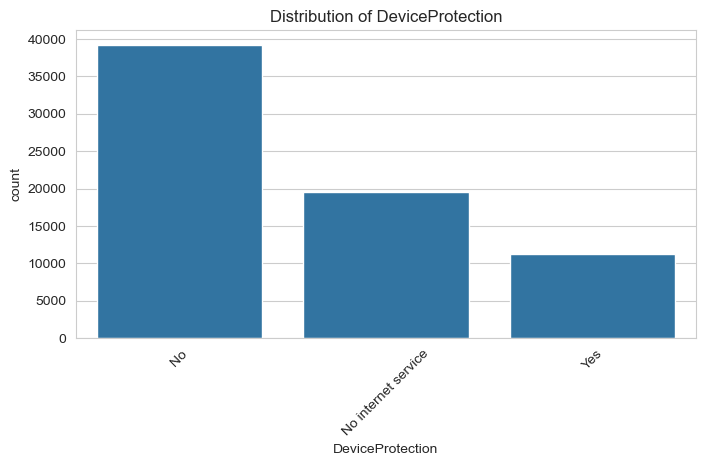

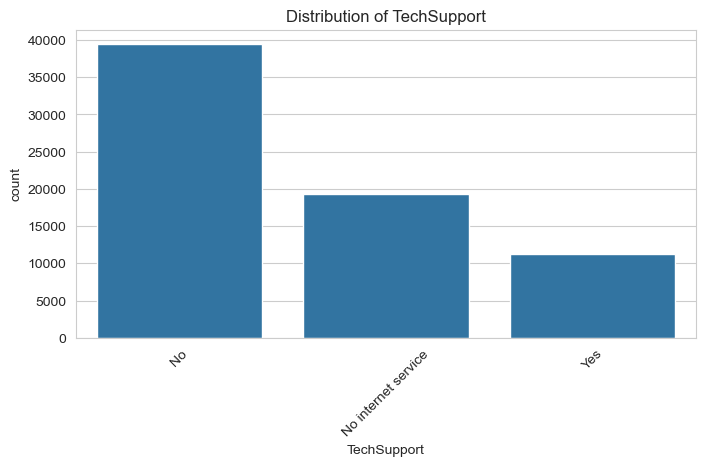

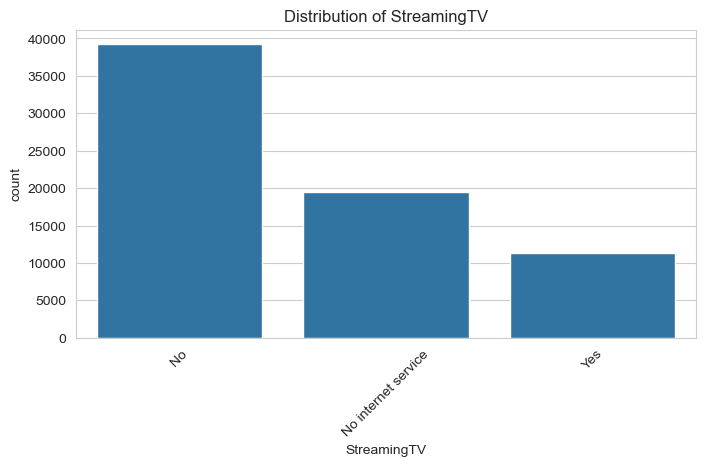

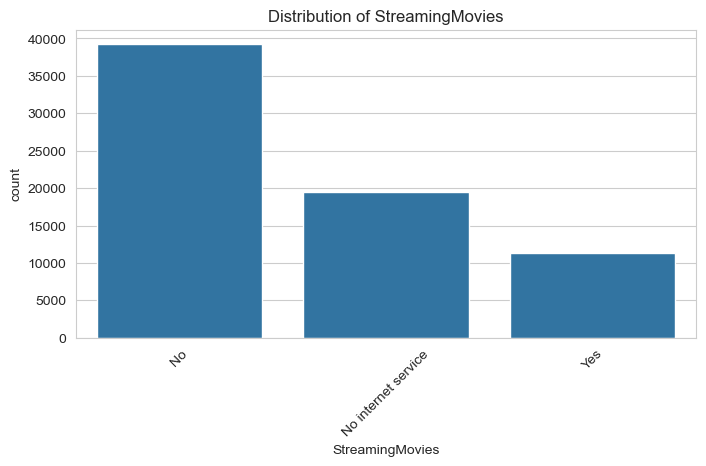

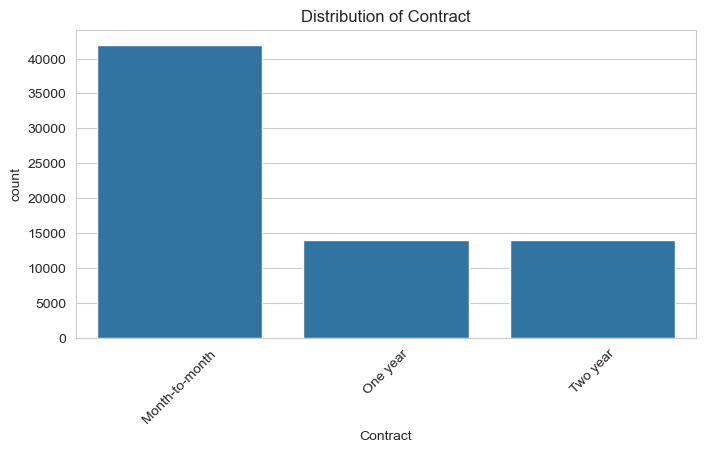

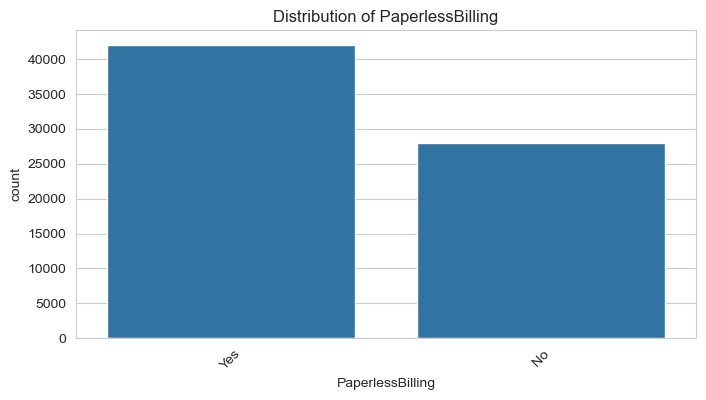

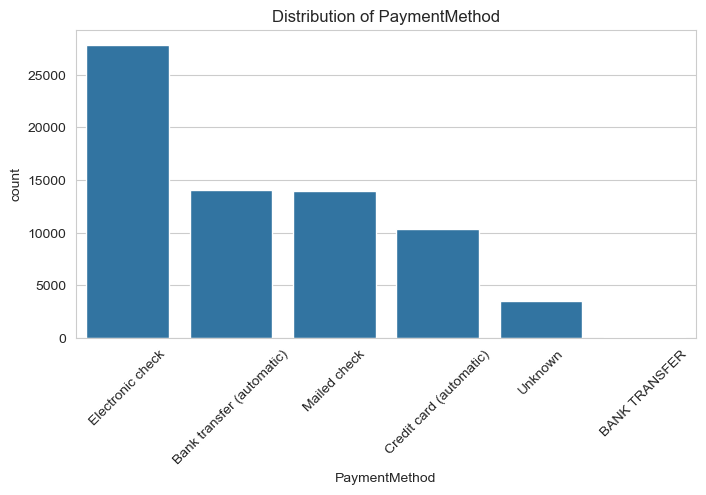

In [12]:
##3 Categorical distributions

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

*FiberOptic is the most adopted internet service 
*Month to Month is the type of contract that dominates 
*Electronic check is the most used payement method 

Bivariate analysis with churn

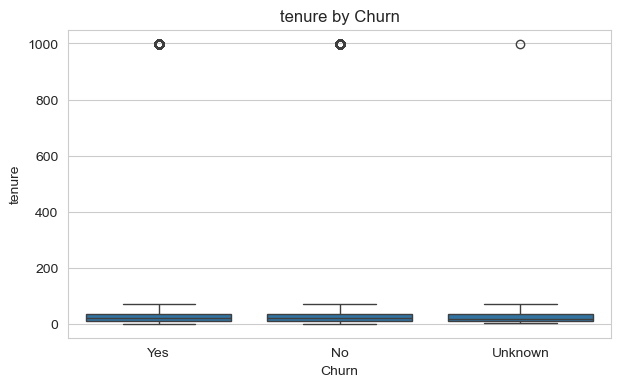

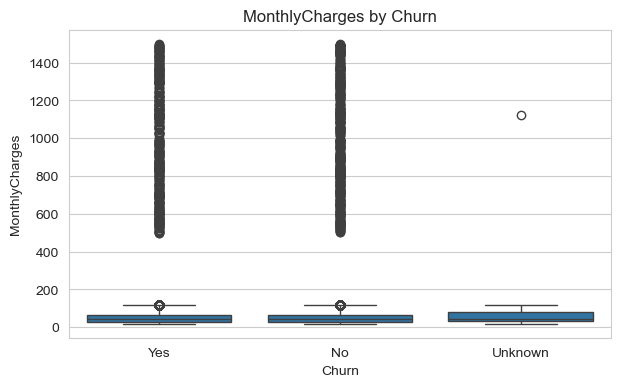

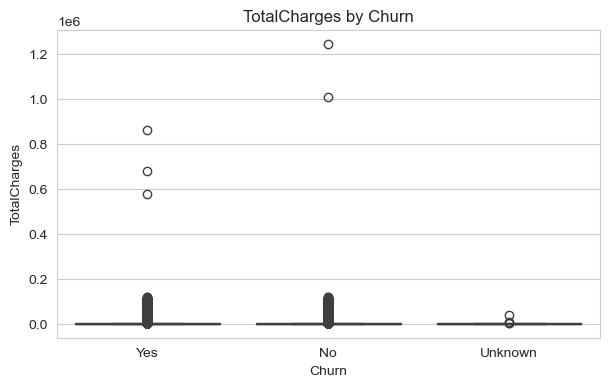

In [13]:
##1 Numeric vs churn
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.show()

In [14]:
for col in numeric_cols:
    grouped = df.groupby("Churn")[col].mean().round(2)
    print(f"\nAverage {col} by Churn:")
    print(grouped)


Average tenure by Churn:
Churn
No         30.94
Unknown    42.91
Yes        31.40
Name: tenure, dtype: float64

Average MonthlyCharges by Churn:
Churn
No         60.58
Unknown    70.83
Yes        60.58
Name: MonthlyCharges, dtype: float64

Average TotalCharges by Churn:
Churn
No         1804.30
Unknown    2008.87
Yes        1823.35
Name: TotalCharges, dtype: float64


*churned customers have almost the same tenure as the non churned ones
*the churned customers pay the same as the non churned customers
*total revenue lower or higher among churned customers

In [ ]:
##2 Categorical vs churn
def churn_rate_table(data, col, target="Churn"):
    table = pd.crosstab(data[col], data[target], normalize="index") * 100
    return table.round(2)


In [17]:
churn_rate_table(df, "Contract")

Churn,No,Unknown,Yes
Contract,,,
Month-to-month,30.17,0.07,69.76
One year,80.00,0.07,19.93
Two year,94.90,0.09,5.01


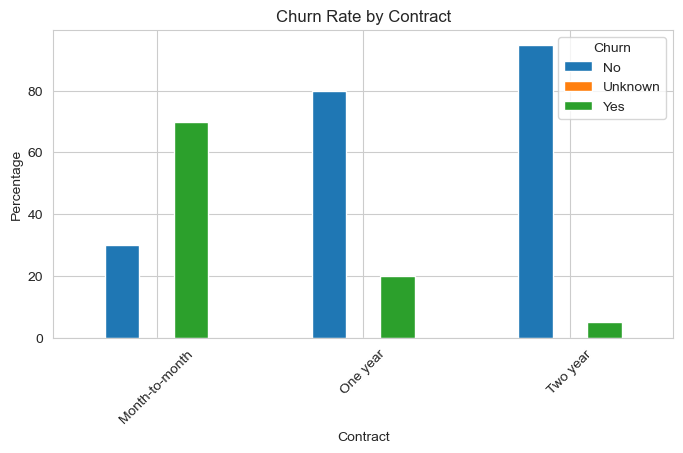

Churn,No,Unknown,Yes
Contract,,,
Month-to-month,30.17,0.07,69.76
One year,80.00,0.07,19.93
Two year,94.90,0.09,5.01


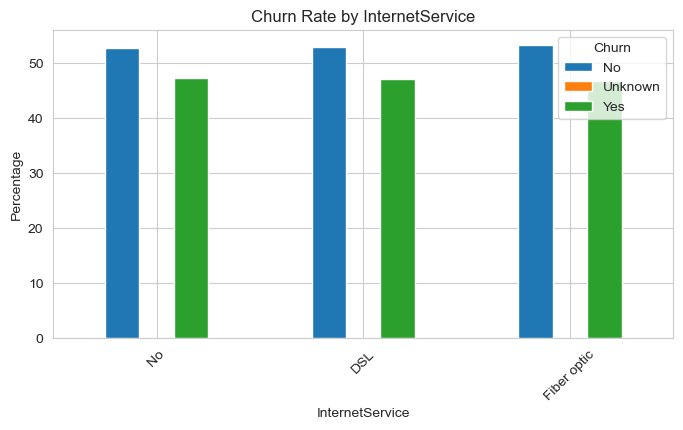

Churn,No,Unknown,Yes
InternetService,,,
No,52.74,0.05,47.21
DSL,52.90,0.09,47.02
Fiber optic,53.26,0.08,46.65


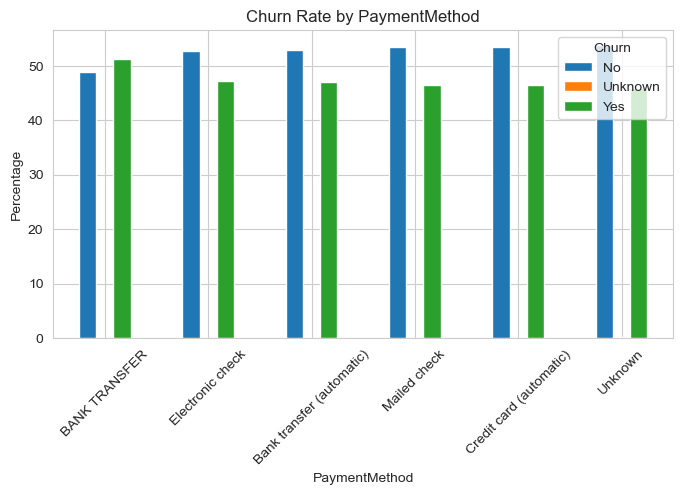

Churn,No,Unknown,Yes
PaymentMethod,,,
BANK TRANSFER,48.80,0.00,51.20
Electronic check,52.69,0.09,47.22
Bank transfer (automatic),52.91,0.09,47.01
Mailed check,53.48,0.03,46.49
Credit card (automatic),53.54,0.07,46.39
Unknown,53.85,0.14,46.01


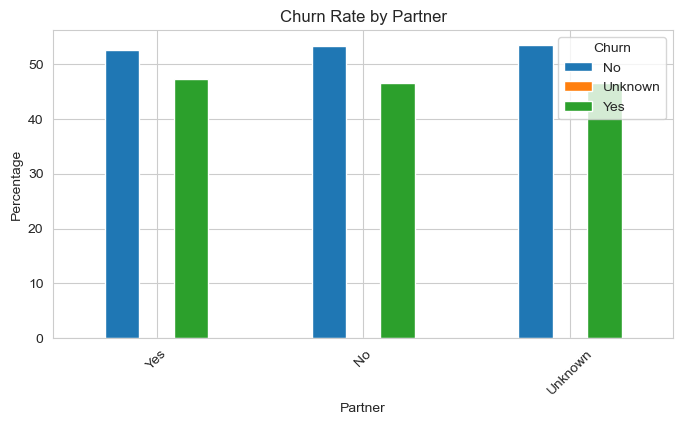

Churn,No,Unknown,Yes
Partner,,,
Yes,52.61,0.07,47.32
No,53.36,0.08,46.55
Unknown,53.48,0.06,46.46


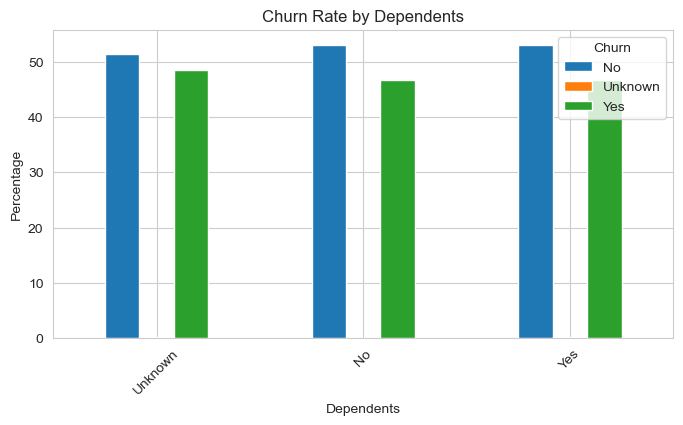

Churn,No,Unknown,Yes
Dependents,,,
Unknown,51.39,0.08,48.53
No,53.16,0.07,46.77
Yes,53.15,0.09,46.76


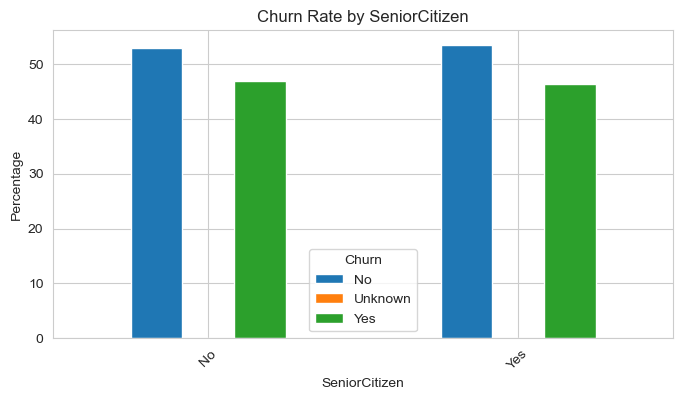

Churn,No,Unknown,Yes
SeniorCitizen,,,
No,52.99,0.08,46.93
Yes,53.52,0.06,46.43


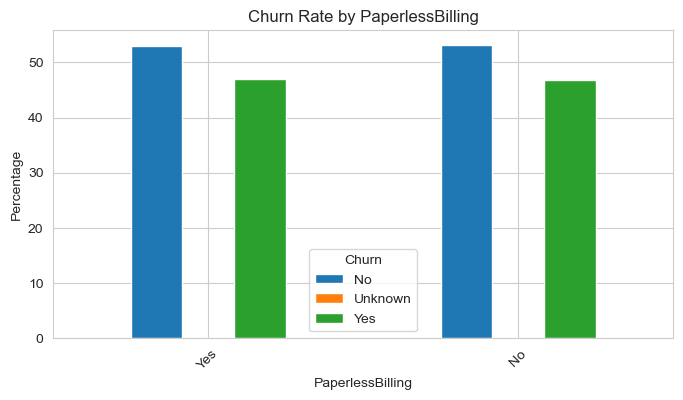

Churn,No,Unknown,Yes
PaperlessBilling,,,
Yes,53.00,0.09,46.91
No,53.17,0.06,46.77


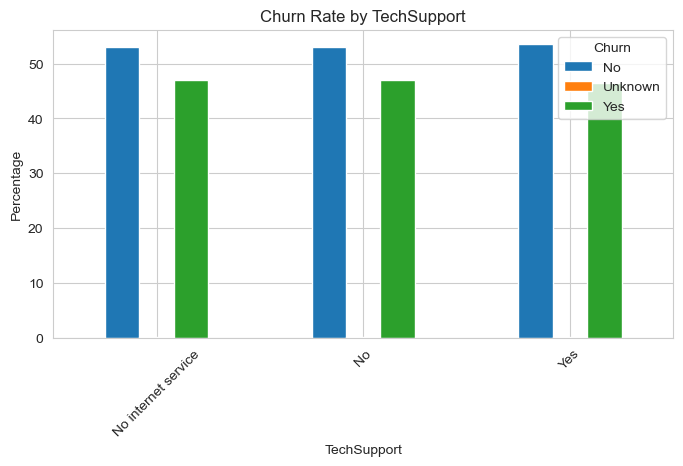

Churn,No,Unknown,Yes
TechSupport,,,
No internet service,52.97,0.06,46.97
No,53.00,0.08,46.92
Yes,53.48,0.10,46.43


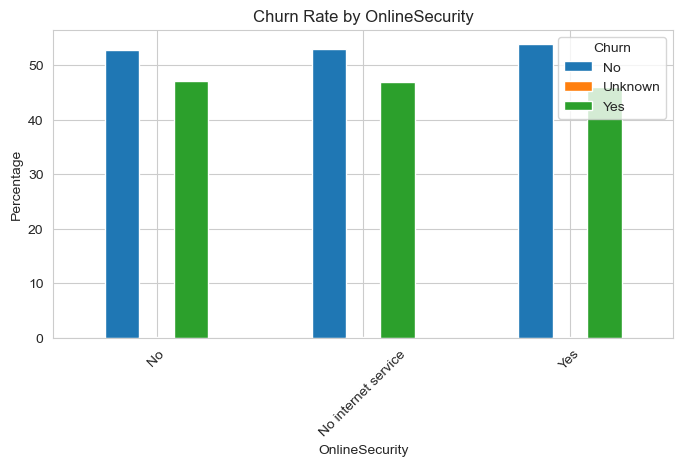

Churn,No,Unknown,Yes
OnlineSecurity,,,
No,52.88,0.08,47.04
No internet service,53.01,0.06,46.93
Yes,53.82,0.11,46.07


In [18]:
important_cat_cols = [
    "Contract", "InternetService", "PaymentMethod",
    "Partner", "Dependents", "SeniorCitizen",
    "PaperlessBilling", "TechSupport", "OnlineSecurity"
]

for col in important_cat_cols:
    churn_rates = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    churn_rates = churn_rates.round(2)

    if "Yes" in churn_rates.columns:
        churn_rates = churn_rates.sort_values(by="Yes", ascending=False)

    churn_rates.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title="Churn")
    plt.show()

    display(churn_rates)

*Month-to-month contracts have the highest churn.
*Customers with  no internet service and no tech support churn more.
*Payment method may be associated with higher churn
*Customers with no online security churn more.

Multivariate analysis

In [21]:
##1 Tenure groups
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

churn_rate_table(df, "tenure_group")


Churn,No,Unknown,Yes
tenure_group,,,
0-12,53.01,0.08,46.90
13-24,52.72,0.07,47.21
25-48,53.35,0.07,46.58
49-72,54.08,0.19,45.73


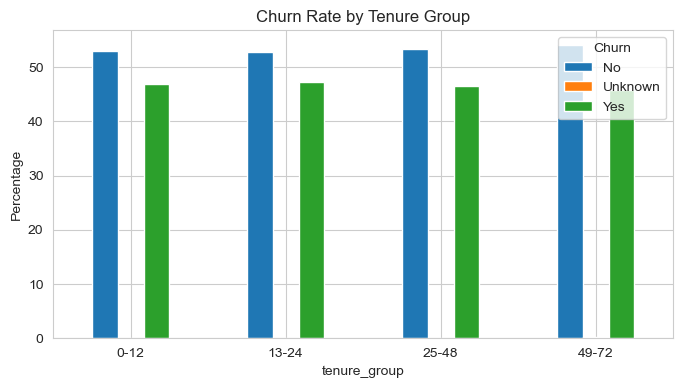

In [22]:
tenure_churn = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100
tenure_churn.round(2).plot(kind="bar", figsize=(8, 4))
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

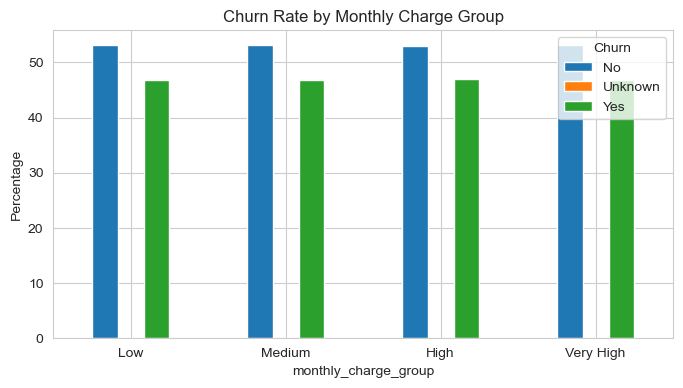

Churn,No,Unknown,Yes
monthly_charge_group,,,
Low,53.14,0.08,46.78
Medium,53.12,0.06,46.82
High,52.95,0.09,46.97
Very High,53.09,0.09,46.82


In [23]:
##2 Monthly charges groups

df["monthly_charge_group"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

charge_churn = pd.crosstab(df["monthly_charge_group"], df["Churn"], normalize="index") * 100
charge_churn.round(2).plot(kind="bar", figsize=(8, 4))
plt.title("Churn Rate by Monthly Charge Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

display(charge_churn.round(2))

C:\Users\USER\AppData\Local\Temp\ipykernel_24084\1599822291.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Contract", "tenure_group", "Churn"])


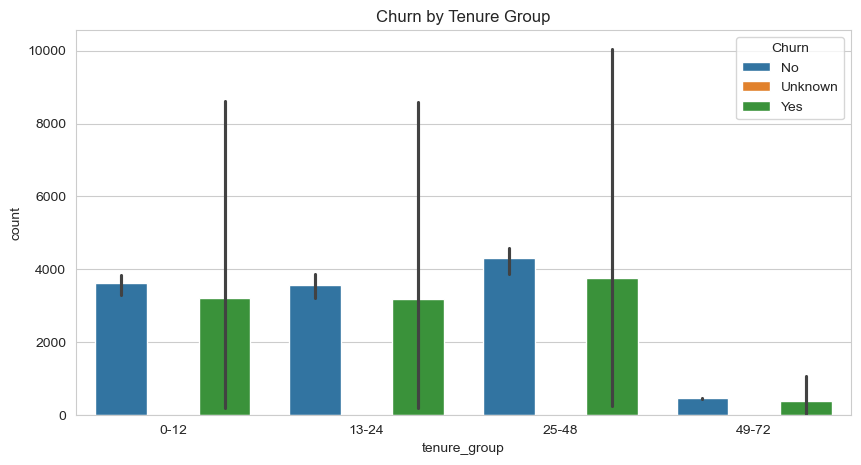

In [24]:
##3 Contract + tenure group
contract_tenure = (
    df.groupby(["Contract", "tenure_group", "Churn"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=contract_tenure,
    x="tenure_group",
    y="count",
    hue="Churn"
)
plt.title("Churn by Tenure Group")
plt.show()

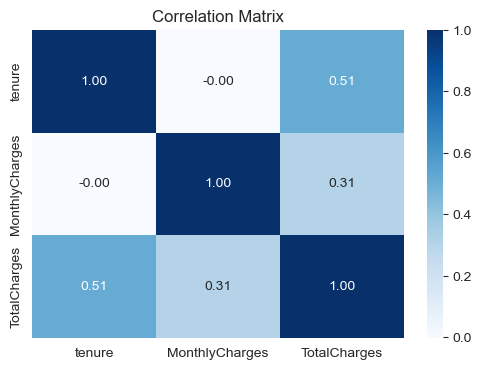

In [25]:
##4 Correlation among numeric variables

plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
##Dashboard recommendations section (optional)